In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("C:/Users/ADMIN/Desktop/Ok/ML/Linear_Regression/California_Housing_Price/train.csv")
real_df = pd.read_csv("C:/Users/ADMIN/Desktop/Ok/ML/Linear_Regression/California_Housing_Price/test.csv")
_df = real_df
df = df.drop(['Id'], axis = 1)
#real_df = real_df.drop(['Id'], axis = 1)
df.head(20)
# for i in df:
#     print(df[i].dtype)
print(df.shape, real_df.shape)
real_df.head(20)

(1460, 80) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
5,1466,60,RL,75.0,10000,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
6,1467,20,RL,NaN,7980,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,GdPrv,Shed,500,3,2010,WD,Normal
7,1468,60,RL,63.0,8402,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
8,1469,20,RL,85.0,10176,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2010,WD,Normal
9,1470,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,4,2010,WD,Normal


In [3]:
# Checking for missing value

numerical_missing_columns = []
too_missing_columns = []

for i in df.columns:
    missing_data = df[i].isna().sum()
    missing_percentage = missing_data/(len(df))*100
    if (df[i].dtype == 'int64' or df[i].dtype == 'float64'):
        #if (missing_percentage != 0):
        if (i != 'SalePrice'):
            numerical_missing_columns.append(i)
    if (missing_percentage >= 90):
        too_missing_columns.append(i)
    print(f"Column {i} has {missing_percentage}% missing data")

Column MSSubClass has 0.0% missing data
Column MSZoning has 0.0% missing data
Column LotFrontage has 17.73972602739726% missing data
Column LotArea has 0.0% missing data
Column Street has 0.0% missing data
Column Alley has 93.76712328767123% missing data
Column LotShape has 0.0% missing data
Column LandContour has 0.0% missing data
Column Utilities has 0.0% missing data
Column LotConfig has 0.0% missing data
Column LandSlope has 0.0% missing data
Column Neighborhood has 0.0% missing data
Column Condition1 has 0.0% missing data
Column Condition2 has 0.0% missing data
Column BldgType has 0.0% missing data
Column HouseStyle has 0.0% missing data
Column OverallQual has 0.0% missing data
Column OverallCond has 0.0% missing data
Column YearBuilt has 0.0% missing data
Column YearRemodAdd has 0.0% missing data
Column RoofStyle has 0.0% missing data
Column RoofMatl has 0.0% missing data
Column Exterior1st has 0.0% missing data
Column Exterior2nd has 0.0% missing data
Column MasVnrType has 59.72

In [4]:
#Processing NaN in numerical columns
house_train_df = df
real_test_df = real_df
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')
house_train_df[numerical_missing_columns] = imputer.fit_transform(house_train_df[numerical_missing_columns])
real_test_df[numerical_missing_columns] = imputer.transform(real_test_df[numerical_missing_columns])
real_test_df.head(20)
#real_test_df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20.0,RH,80.000000,11622.0,Pave,NaN,Reg,Lvl,AllPub,...,120.0,0.0,NaN,MnPrv,NaN,0.0,6.0,2010.0,WD,Normal
1,1462,20.0,RL,81.000000,14267.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,0.0,NaN,NaN,Gar2,12500.0,6.0,2010.0,WD,Normal
2,1463,60.0,RL,74.000000,13830.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,0.0,NaN,MnPrv,NaN,0.0,3.0,2010.0,WD,Normal
3,1464,60.0,RL,78.000000,9978.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,0.0,NaN,NaN,NaN,0.0,6.0,2010.0,WD,Normal
4,1465,120.0,RL,43.000000,5005.0,Pave,NaN,IR1,HLS,AllPub,...,144.0,0.0,NaN,NaN,NaN,0.0,1.0,2010.0,WD,Normal
5,1466,60.0,RL,75.000000,10000.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,0.0,NaN,NaN,NaN,0.0,4.0,2010.0,WD,Normal
6,1467,20.0,RL,70.049958,7980.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,0.0,NaN,GdPrv,Shed,500.0,3.0,2010.0,WD,Normal
7,1468,60.0,RL,63.000000,8402.0,Pave,NaN,IR1,Lvl,AllPub,...,0.0,0.0,NaN,NaN,NaN,0.0,5.0,2010.0,WD,Normal
8,1469,20.0,RL,85.000000,10176.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,0.0,NaN,NaN,NaN,0.0,2.0,2010.0,WD,Normal
9,1470,20.0,RL,70.000000,8400.0,Pave,NaN,Reg,Lvl,AllPub,...,0.0,0.0,NaN,MnPrv,NaN,0.0,4.0,2010.0,WD,Normal


<Axes: >

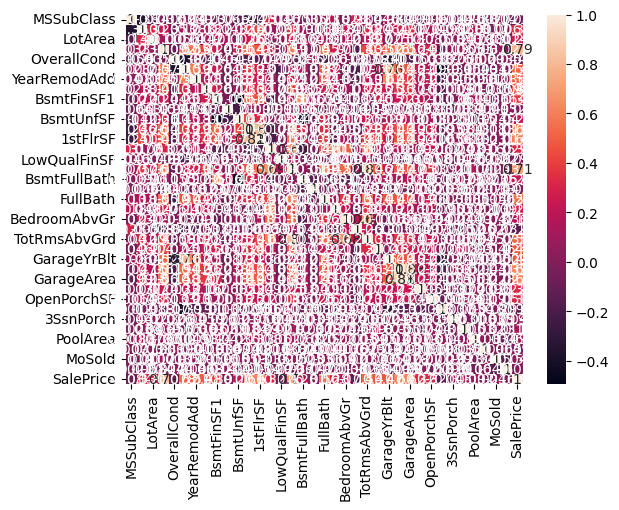

In [115]:
#Check the correlation among the variables
num_cols = []
for i in house_train_df.columns:
    if (house_train_df[i].dtype == float or house_train_df[i].dtype == int):
       num_cols.append(i)

house_train_df_numerical = house_train_df[num_cols]
house_train_df_numerical_corr = house_train_df_numerical.corr()
sns.heatmap(data = house_train_df_numerical_corr, annot = True)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8448\717965282.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(house_train_df['SalePrice'], bins = 50, color = 'r', ax = ax)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8448\717965282.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log10(ho

Text(0.5, 1.0, 'Distribution of SalePrice in $log$')

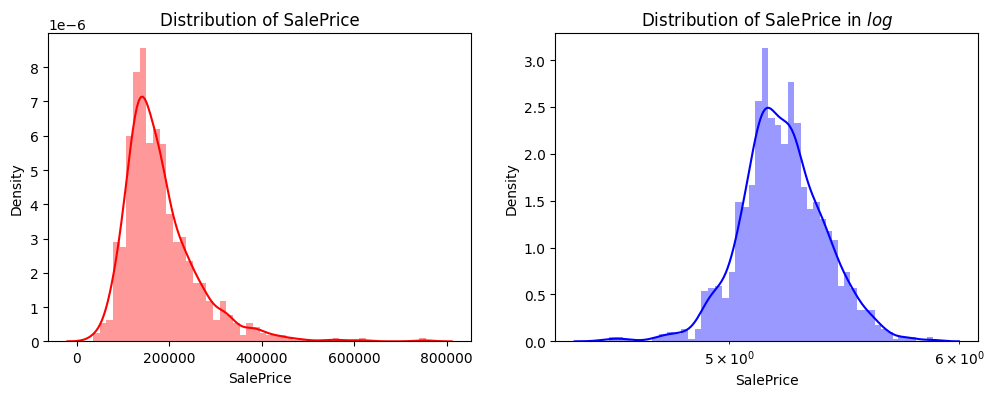

In [144]:
#Check the contribution of insurance charges
f = plt.figure (figsize = (12,4))

ax = f.add_subplot(121)
sns.distplot(house_train_df['SalePrice'], bins = 50, color = 'r', ax = ax)
ax.set_title("Distribution of SalePrice")

#Left-skewed -> use log to fix it
ax = f.add_subplot(122)
sns.distplot(np.log10(house_train_df['SalePrice']), bins = 50, color = 'b', ax = ax)
ax.set_xscale('log')
ax.set_title("Distribution of SalePrice in $log$")

In [6]:
too_missing_columns

['Alley', 'PoolQC', 'MiscFeature']

In [7]:
house_train_df.drop(too_missing_columns, axis = 1)
real_test_df.drop(too_missing_columns, axis = 1)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,Fence,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20.0,RH,80.0,11622.0,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,120.0,0.0,MnPrv,0.0,6.0,2010.0,WD,Normal
1,1462,20.0,RL,81.0,14267.0,Pave,IR1,Lvl,AllPub,Corner,...,0.0,0.0,0.0,0.0,NaN,12500.0,6.0,2010.0,WD,Normal
2,1463,60.0,RL,74.0,13830.0,Pave,IR1,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,MnPrv,0.0,3.0,2010.0,WD,Normal
3,1464,60.0,RL,78.0,9978.0,Pave,IR1,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,NaN,0.0,6.0,2010.0,WD,Normal
4,1465,120.0,RL,43.0,5005.0,Pave,IR1,HLS,AllPub,Inside,...,0.0,0.0,144.0,0.0,NaN,0.0,1.0,2010.0,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160.0,RM,21.0,1936.0,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,NaN,0.0,6.0,2006.0,WD,Normal
1455,2916,160.0,RM,21.0,1894.0,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,NaN,0.0,4.0,2006.0,WD,Abnorml
1456,2917,20.0,RL,160.0,20000.0,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,NaN,0.0,9.0,2006.0,WD,Abnorml
1457,2918,85.0,RL,62.0,10441.0,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,MnPrv,700.0,7.0,2006.0,WD,Normal


In [8]:
#Dummy variable trap
cate_cols = []
for i in house_train_df.columns:
    if (house_train_df[i].dtype == object):
        cate_cols.append(i)
print(cate_cols)

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [31]:
#Processing NaN in categorical columns
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

house_train_tmp_df = house_train_df.drop('SalePrice', axis = 1)
real_test_df = real_test_df.drop('Id', axis = 1)

ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(sparse_output = False, handle_unknown = 'ignore'), cate_cols)], remainder = "passthrough")

encoded_train = ct.fit_transform(house_train_tmp_df)
encoded_cols = ct.get_feature_names_out()

encoded_test = ct.transform(real_test_df)

categorical_df = pd.DataFrame(encoded_train, columns = encoded_cols, index = house_train_tmp_df.index)
test_categorical_df = pd.DataFrame(encoded_test, columns = encoded_cols, index = real_test_df.index)

numerical_df = house_train_tmp_df.drop(columns = cate_cols)
test_numerical_df = real_test_df.drop(columns = cate_cols)

house_train_df_encode = pd.concat([numerical_df, categorical_df], axis = 1)
real_test_df_encode = pd.concat([test_numerical_df, test_categorical_df], axis = 1)

house_train_df_encode['SalePrice'] = house_train_df['SalePrice']

In [32]:
# house_train_df_encode = pd.get_dummies(data = house_train_df, 
#                                       columns = cate_cols,
#                                       drop_first = True,
#                                       dtype = 'int64')

# real_test_df_encode = pd.get_dummies(data = real_test_df,
#                                     columns = cate_cols,
#                                     drop_first = True,
#                                     dtype = 'int64')
# #fix columns of real_test base on data_set
# if ('SalePrice' in house_train_df_encode):
#     print("CHELSEA")

# real_test_df_encode = real_test_df_encode.reindex(columns = house_train_df_encode.columns, fill_value = 0)

# if ('SalePrice' in real_test_df_encode):
#     print("CHELSEA")

# real_test_df_encode = real_test_df_encode.drop('SalePrice', axis = 1)

# if ('SalePrice' not in real_test_df_encode):
#     print("MAN UTD")

# #Verify the dummy variable process
# #print("Columns in the original data frame: ", house_train_df.columns.values)
# print("Shape of the data set: ", house_train_df.shape)
# print("Shape of the test: ", real_df.shape)
# #print("Columns in the original data frame after encoding dummy variables: ", house_train_df_encode.columns.values)
# #print("Columns in the test data frame after encoding dummy variables: ", real_test_df_encode.columns.values)
# print("Shape of the data set after encoding dummy variables: ", house_train_df_encode.shape)
# print("Shape of the test after encoding dummy variables: ", real_test_df_encode.shape)

In [33]:
# real_test_df_encode = real_test_df_encode.reindex(columns = house_train_df_encode.columns.values, fill_value = 0)
# real_test_df_encode = real_test_df_encode.fillna(0)

for i in real_test_df_encode.columns:
    missing_data = real_test_df_encode[i].isna().sum()
    missing_percentage = missing_data/(len(real_test_df_encode))*100
    print(f"Column {i} has {missing_percentage}% missing data")

Column MSSubClass has 0.0% missing data
Column LotFrontage has 0.0% missing data
Column LotArea has 0.0% missing data
Column OverallQual has 0.0% missing data
Column OverallCond has 0.0% missing data
Column YearBuilt has 0.0% missing data
Column YearRemodAdd has 0.0% missing data
Column MasVnrArea has 0.0% missing data
Column BsmtFinSF1 has 0.0% missing data
Column BsmtFinSF2 has 0.0% missing data
Column BsmtUnfSF has 0.0% missing data
Column TotalBsmtSF has 0.0% missing data
Column 1stFlrSF has 0.0% missing data
Column 2ndFlrSF has 0.0% missing data
Column LowQualFinSF has 0.0% missing data
Column GrLivArea has 0.0% missing data
Column BsmtFullBath has 0.0% missing data
Column BsmtHalfBath has 0.0% missing data
Column FullBath has 0.0% missing data
Column HalfBath has 0.0% missing data
Column BedroomAbvGr has 0.0% missing data
Column KitchenAbvGr has 0.0% missing data
Column TotRmsAbvGrd has 0.0% missing data
Column Fireplaces has 0.0% missing data
Column GarageYrBlt has 0.0% missing 

In [34]:
print("Shape of test: ", real_test_df_encode.shape)
#real_test_df_encode = real_test_df_encode.drop('SalePrice', axis = 1)
#print(house_train_df_encode.columns.values)
#print(real_test_df_encode.columns.values)

Shape of test:  (1459, 339)


In [35]:
arr = []
for i in house_train_df_encode.columns.values:
    if (i not in real_test_df_encode.columns.values):
        arr.append(i)

print(arr)

['SalePrice']


In [36]:
#Box-cox
from scipy.stats import boxcox
y_bc, lam, ci = boxcox(house_train_df_encode['SalePrice'], alpha = 0.05)
ci, lam

((-0.16782925421713532, 0.014467035560866133),
 np.float64(-0.07692397686078907))

In [37]:
#log transform
house_train_df_encode['SalePrice'] = np.log(house_train_df_encode['SalePrice'])

In [38]:
#Test train split
from sklearn.model_selection import train_test_split
X = house_train_df_encode.drop('SalePrice', axis = 1)
y = house_train_df_encode['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3, random_state = 42)

In [39]:
#Use Sklearn to process Linear Regression
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

theta = [lin_reg.intercept_] + list(lin_reg.coef_)
print(theta)

[np.float64(5.2734925983598115), np.float64(-5.246954792392728e-05), np.float64(0.00021255439829743404), np.float64(1.1021130614432073e-06), np.float64(0.021607304111044195), np.float64(0.017573556104214107), np.float64(0.0010190573391733297), np.float64(0.0005393028820427386), np.float64(4.853757094616372e-06), np.float64(2.170199782180313e-05), np.float64(2.355823137492575e-05), np.float64(6.278823827413158e-07), np.float64(4.588816255223063e-05), np.float64(7.360537963942257e-06), np.float64(1.915885165327093e-05), np.float64(6.014732500479237e-05), np.float64(8.666670986782598e-05), np.float64(0.014740831693814994), np.float64(0.004983387192089413), np.float64(0.010292914728239136), np.float64(0.014110851174695212), np.float64(0.004822358095277255), np.float64(-0.021481749702230282), np.float64(0.0033799417532939437), np.float64(0.008030195527454308), np.float64(-0.00023285751868145927), np.float64(0.004613969425063266), np.float64(8.67686571674204e-05), np.float64(4.46172919950169

In [40]:
#Model Evaluation

## Normal Equation
y_pred = lin_reg.predict(X_test)

## MSE
from sklearn.metrics import mean_squared_error
J_mse = mean_squared_error(y_pred, y_test)

# R Square
R_square = lin_reg.score(X_test, y_test)

print(J_mse, R_square)

0.020411020678149535 0.879684750439865


In [41]:
tmp = pd.DataFrame({"tmp": np.exp(y_pred), "Check": np.exp(y_test)})
tmp

,tmp,Check
892,151252.143784,154500.0
1105,348645.816616,325000.0
413,101379.155206,115000.0
522,172045.977699,159000.0
1036,320991.345421,315500.0
...,...,...
331,137851.470528,139000.0
323,121990.002969,126175.0
650,209958.433868,205950.0
439,112780.790214,110000.0


In [42]:
#answer = lin_reg.predict(real_test_df_encode)
X_test

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,remainder__GarageArea,remainder__WoodDeckSF,remainder__OpenPorchSF,remainder__EnclosedPorch,remainder__3SsnPorch,remainder__ScreenPorch,remainder__PoolArea,remainder__MiscVal,remainder__MoSold,remainder__YrSold
892,20.0,70.0,8414.0,6.0,8.0,1963.0,2003.0,0.000000,663.0,0.0,...,264.0,192.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2006.0
1105,60.0,98.0,12256.0,8.0,5.0,1994.0,1995.0,362.000000,1032.0,0.0,...,712.0,186.0,32.0,0.0,0.0,0.0,0.0,0.0,4.0,2010.0
413,30.0,56.0,8960.0,5.0,6.0,1927.0,1950.0,0.000000,0.0,0.0,...,360.0,0.0,0.0,130.0,0.0,0.0,0.0,0.0,3.0,2010.0
522,50.0,50.0,5000.0,6.0,7.0,1947.0,1950.0,0.000000,399.0,0.0,...,420.0,0.0,24.0,36.0,0.0,0.0,0.0,0.0,10.0,2006.0
1036,20.0,89.0,12898.0,9.0,5.0,2007.0,2008.0,70.000000,1022.0,0.0,...,912.0,228.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,2009.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,20.0,70.0,8176.0,5.0,6.0,1958.0,1992.0,0.000000,846.0,0.0,...,308.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,2007.0
323,20.0,49.0,5820.0,3.0,8.0,1955.0,2005.0,0.000000,256.0,0.0,...,220.0,142.0,98.0,0.0,0.0,0.0,0.0,0.0,7.0,2006.0
650,60.0,65.0,8125.0,7.0,6.0,2007.0,2007.0,103.685262,0.0,0.0,...,562.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2008.0
439,50.0,67.0,12354.0,6.0,8.0,1920.0,2000.0,0.000000,0.0,0.0,...,528.0,0.0,46.0,0.0,0.0,0.0,0.0,800.0,8.0,2009.0


In [44]:
#real_test_df_encode.drop("Id", axis = 1)

In [45]:
real_df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [46]:
ans = lin_reg.predict(real_test_df_encode)
print(len(ans))

1459


In [47]:
answer = pd.DataFrame({"Id": _df["Id"], "SalePrice": np.exp(ans)})
answer

,Id,SalePrice
0,1461,125330.794064
1,1462,162496.109401
2,1463,181436.404931
3,1464,197817.525832
4,1465,194980.486775
...,...,...
1454,2915,80014.695888
1455,2916,89627.622912
1456,2917,178834.181256
1457,2918,116591.512750


In [48]:
np.exp(y_train)

135     174000.0
1452    145000.0
762     215200.0
932     320000.0
435     212000.0
          ...   
1095    176432.0
1130    135000.0
1294    115000.0
860     189950.0
1126    174000.0
Name: SalePrice, Length: 1022, dtype: float64

In [49]:
answer.to_csv("house_pricing_answer.csv", index = False)